In [1]:
import pandas as pd

In [3]:
file_path = r'data/customerdata4.csv'
data = pd.read_csv(file_path)

In [5]:
data.head(), data.describe()

(   CustomerID  Gender  Age  Annual Income (10kkr)  Spending Score (1-100)
 0           1    Male   19                     15                      39
 1           2    Male   21                     15                      81
 2           3  Female   20                     16                       6
 3           4  Female   23                     16                      77
 4           5  Female   31                     17                      40,
        CustomerID         Age  Annual Income (10kkr)  Spending Score (1-100)
 count  200.000000  200.000000             200.000000              200.000000
 mean   100.500000   38.850000              60.560000               50.200000
 std     57.879185   13.969007              26.264721               25.823522
 min      1.000000   18.000000              15.000000                1.000000
 25%     50.750000   28.750000              41.500000               34.750000
 50%    100.500000   36.000000              61.500000               50.000000
 75

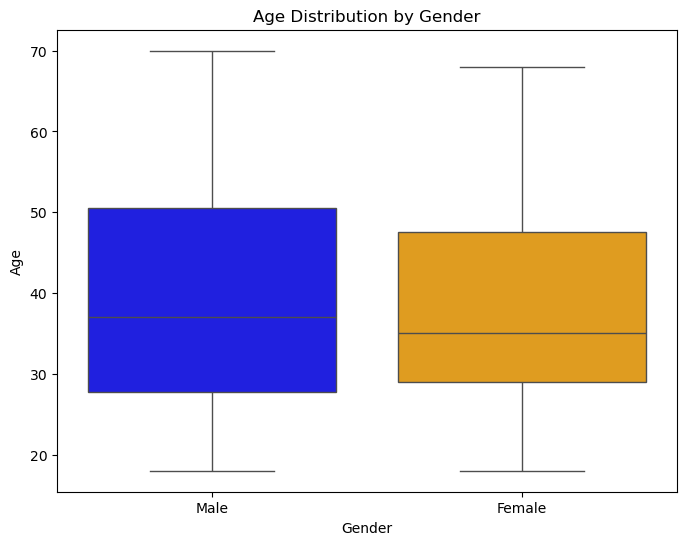

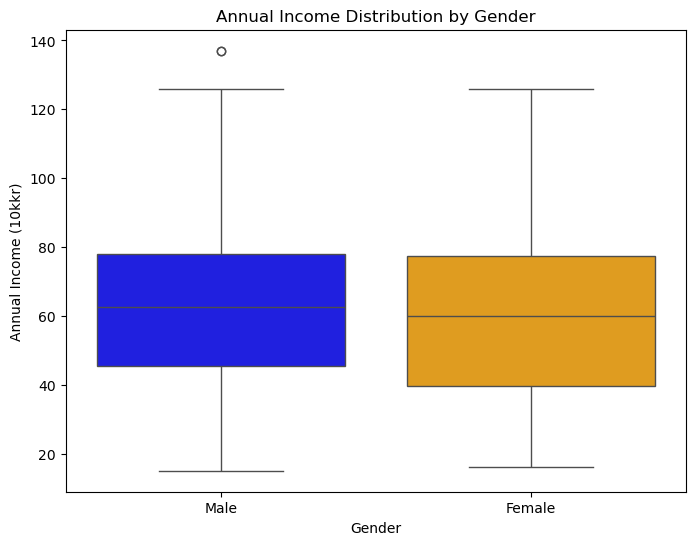

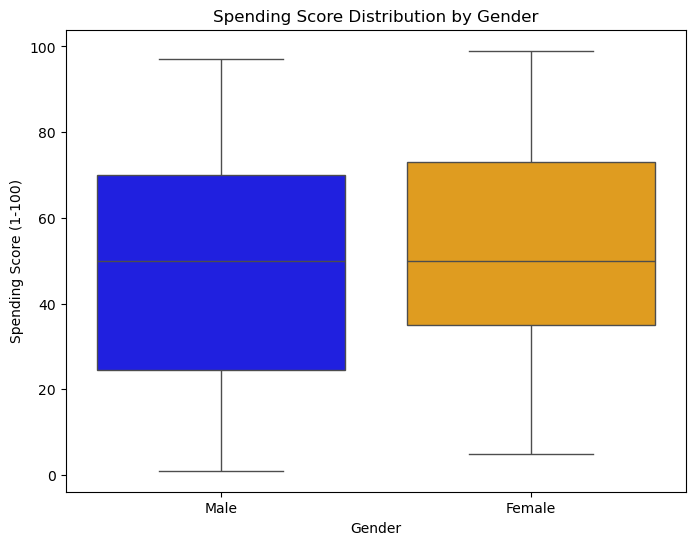

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Age', data=data, hue='Gender', dodge=False, palette={'Male': 'blue', 'Female': 'orange'})
plt.title('Age Distribution by Gender')
plt.legend([],[], frameon=False)  # Remove duplicate legends
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Annual Income (10kkr)', data=data, hue='Gender', dodge=False, palette={'Male': 'blue', 'Female': 'orange'})
plt.title('Annual Income Distribution by Gender')
plt.legend([],[], frameon=False)  # Remove duplicate legends
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=data, hue='Gender', dodge=False, palette={'Male': 'blue', 'Female': 'orange'})
plt.title('Spending Score Distribution by Gender')
plt.legend([],[], frameon=False)  # Remove duplicate legends
plt.show()

C:\Users\User-9100\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


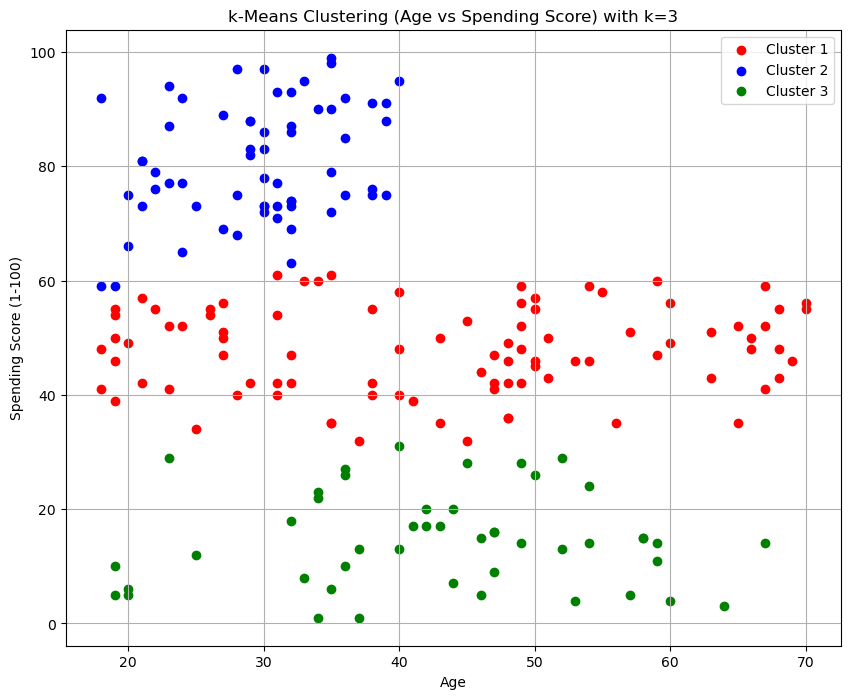

array([[43.05494505, 47.78021978],
       [29.56451613, 80.74193548],
       [42.95744681, 14.59574468]])

In [9]:
#Klustring av Ålder och Spenderingspoäng med k-Means (k=3)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Prepare the data for clustering
X = data[['Age', 'Spending Score (1-100)']].values

# Perform k-means clustering with the optimal number of clusters (k=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green']
for cluster in range(optimal_k):
    cluster_points = data[data['Cluster'] == cluster]
    plt.scatter(cluster_points['Age'], cluster_points['Spending Score (1-100)'],
                label=f'Cluster {cluster+1}', color=colors[cluster])

# Add plot details
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('k-Means Clustering (Age vs Spending Score) with k=3')
plt.legend()
plt.grid()
plt.show()

# Display cluster centroids
centroids = kmeans.cluster_centers_
centroids


C:\Users\User-9100\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User-9100\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User-9100\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User-9100\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memor

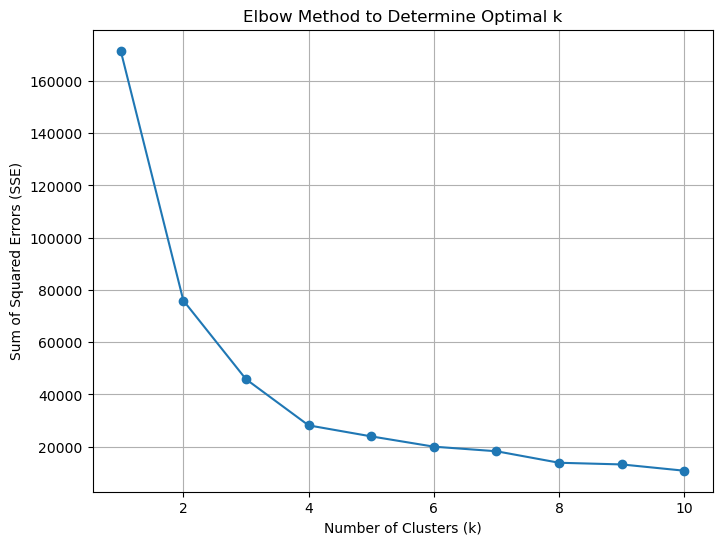

C:\Users\User-9100\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


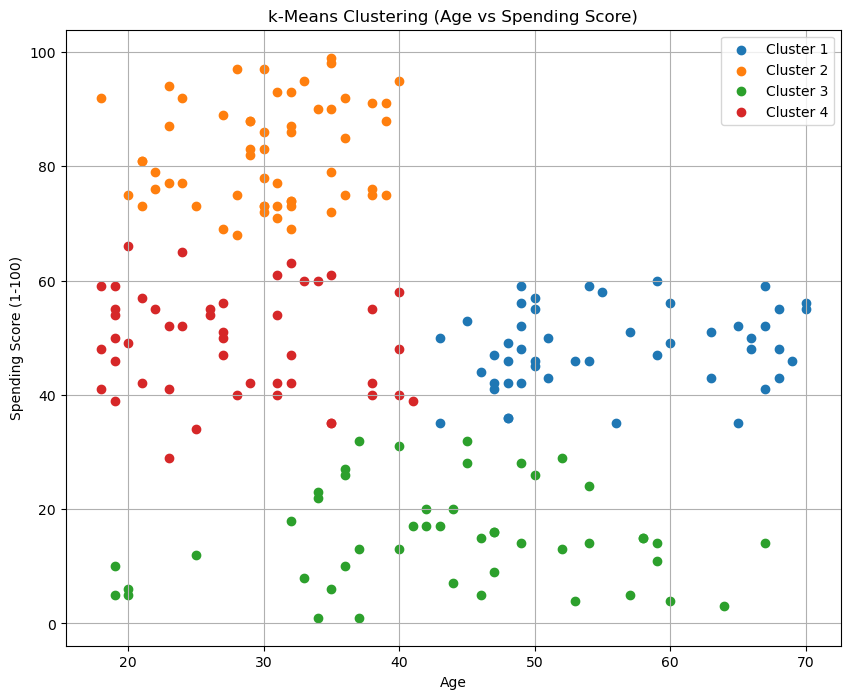

In [11]:
#Elbow-metoden och k-Means Klustring av Ålder och Spenderingspoäng (k=4)

#Import necessary libraries
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Prepare the data for clustering (only Age and Spending Score columns)
X = data[['Age', 'Spending Score (1-100)']].values

# Determine the optimal number of clusters using the Elbow Method
sse = []  # Sum of Squared Errors for each k
k_values = range(1, 11)  # Test k from 1 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # Append the SSE for the current k

# Plot the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(k_values, sse, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method to Determine Optimal k')
plt.grid()
plt.show()

# Choose k based on the elbow point (let's assume k=4 for now) and fit the model
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(10, 8))
for cluster in range(optimal_k):
    cluster_points = data[data['Cluster'] == cluster]
    plt.scatter(cluster_points['Age'], cluster_points['Spending Score (1-100)'], label=f'Cluster {cluster+1}')

plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('k-Means Clustering (Age vs Spending Score)')
plt.legend()
plt.grid()
plt.show()

C:\Users\User-9100\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User-9100\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User-9100\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User-9100\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memor

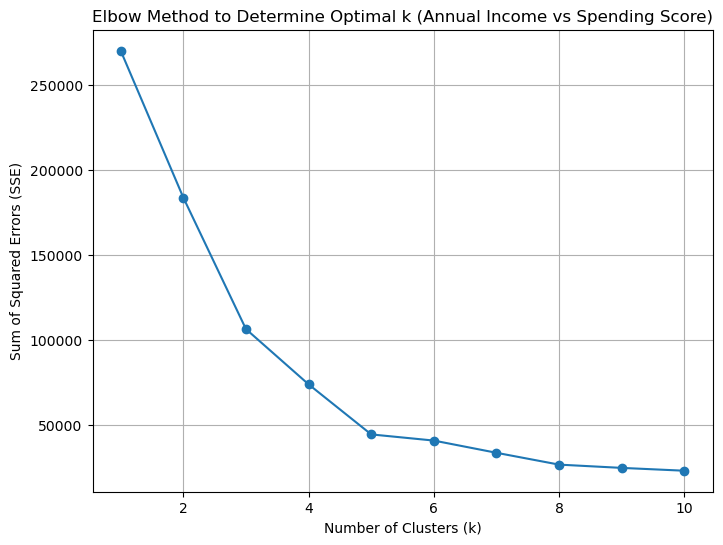

In [13]:
#Elbow-metoden och k-Means Klustring av Årsinkomst och Spenderingspoäng

# Prepare the data for clustering (Annual Income and Spending Score)
X_income_score = data[['Annual Income (10kkr)', 'Spending Score (1-100)']].values

# Determine the optimal number of clusters using the Elbow Method
sse_income_score = []
k_values_income_score = range(1, 11)

for k in k_values_income_score:
    kmeans_income_score = KMeans(n_clusters=k, random_state=42)
    kmeans_income_score.fit(X_income_score)
    sse_income_score.append(kmeans_income_score.inertia_)

# Plot the Elbow Method graph for Annual Income vs Spending Score
plt.figure(figsize=(8, 6))
plt.plot(k_values_income_score, sse_income_score, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method to Determine Optimal k (Annual Income vs Spending Score)')
plt.grid()
plt.show()

C:\Users\User-9100\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


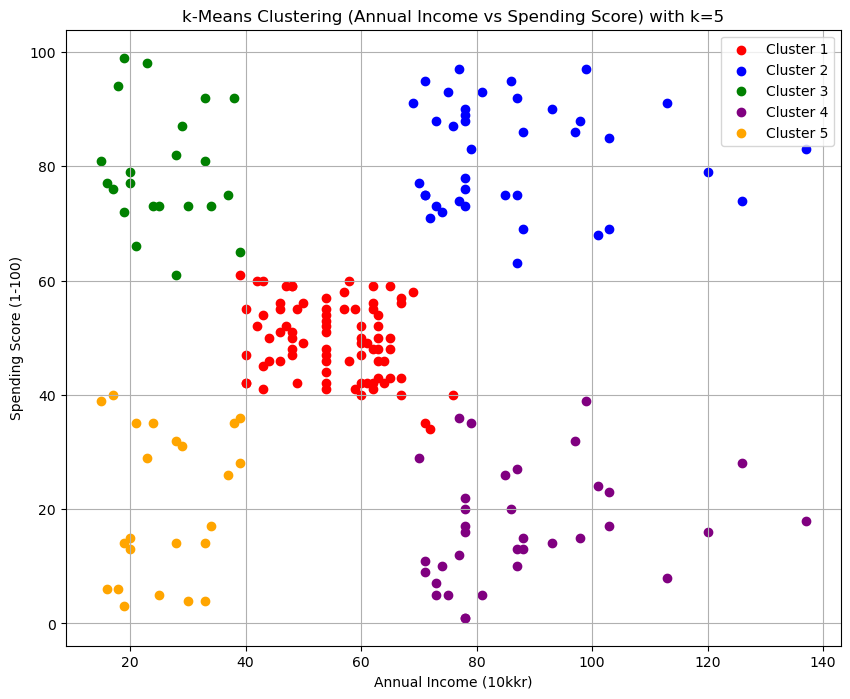

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [15]:
#Visualisering av k-Means Klustring för Årsinkomst och Spenderingspoäng (k=5)

from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Prepare the data for clustering (Annual Income and Spending Score)
X_income_score = data[['Annual Income (10kkr)', 'Spending Score (1-100)']].values

# Perform k-means clustering with the optimal number of clusters (k=5)
optimal_k_income_score = 5
kmeans_income_score = KMeans(n_clusters=optimal_k_income_score, random_state=42)
data['Cluster_Income_Score'] = kmeans_income_score.fit_predict(X_income_score)

# Visualize the clusters
plt.figure(figsize=(10, 8))
cluster_colors = ['red', 'blue', 'green', 'purple', 'orange']
for cluster in range(optimal_k_income_score):
    cluster_points = data[data['Cluster_Income_Score'] == cluster]
    plt.scatter(cluster_points['Annual Income (10kkr)'], cluster_points['Spending Score (1-100)'], 
                label=f'Cluster {cluster+1}', color=cluster_colors[cluster])

# Add plot details
plt.xlabel('Annual Income (10kkr)')
plt.ylabel('Spending Score (1-100)')
plt.title('k-Means Clustering (Annual Income vs Spending Score) with k=5')
plt.legend()
plt.grid()
plt.show()

# Display cluster centroids
centroids_income_score = kmeans_income_score.cluster_centers_
centroids_income_score
